# Using Edges in BONSAI: Spatializing Water Scarcity Impacts of French Consumption 

**Brightcon 2026** · Dr Denise Almeida (2-0 LCA), Fan Yang (2-0 LCA), Mathieu Delpierre (2-0 LCA), Miguel Fernández Astudillo (2-0 LCA), Dr Stefano Merciai (2-0 LCA), Valentin Starlinger (2-0 LCA)

---

We integrate the [`edges`](https://github.com/romainsacchi/edges) library with the
[BONSAI](https://bonsai.uno/) database to run exchange-based, geographically explicit LCIA:
characterisation factors conditioned on where an exchange happens and what consumes it.

Why this matters:

* **It shows what BONSAI and `edges` can do together.** BONSAI covers the whole economy, every
  sector and country, with no cut-off, and every activity has a location. `edges` uses that
  location (and, if available, the sector) to pick the right characterisation factor for each
  exchange. Both are open, so the whole calculation can be reproduced.
* **It is a real example.** We calculate the water scarcity footprint (AWARE 2.0) of French
  household consumption and look at where in the world it happens.
* **It shows why regionalised data matter,** and how little work it takes with BONSAI: the
  result and the ranking of countries change a lot compared with a global average.

## Contents:
1. Why an edge needs its own factor
2. Why `edges` and BONSAI
3. The calculation
4. Where French consumption causes water scarcity
5. What regionalisation changes
6. What is next

---
## 0 Setup
*run before the talk starts*
Imports, plotting defaults, configuration, inventory.

**Info:** cells that only draw a chart start with `# Plot:` and are collapsed so it is easier to follow the main points; click
the bar on the left of a cell to open it. The cell before each chart computes and shows the data
the chart is drawn from.

In [34]:
from __future__ import annotations

import contextlib
import io as _io
import json
import logging
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import plotly.express as px
import country_converter as coco

import bw2data as bd
import edges
from edges import EdgeLCIA

from edges.filesystem_constants import DATA_DIR as EDGES_DATA_DIR

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

logging.getLogger("country_converter").setLevel(logging.ERROR)
_CC = coco.CountryConverter()      # country codes: rest-of-world regions and country names

In [35]:
# Plot helpers: colours, fonts and small functions used by the charts (styling only).
# ---------------------------------------------------------------------------
# Plotting defaults used throughout.
# Palette: 3 categorical colours (blue / orange / aqua), checked for colour-vision
# deficiency; single-hue blue ramp for magnitudes; low-contrast ink and gridlines.
# ---------------------------------------------------------------------------
INK, INK_2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, SURFACE, FILL_GREY = "#e1e0d9", "#fcfcfb", "#d5d4cd"
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
SEQ_BLUE = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200,
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": "sans-serif", "font.size": 10,
    "axes.edgecolor": GRID, "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.titlepad": 12, "axes.labelsize": 9.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "grid.color": GRID, "grid.linewidth": 0.8, "grid.linestyle": "-",
    "legend.frameon": False, "legend.fontsize": 9, "legend.labelcolor": INK_2,
    "lines.linewidth": 2, "lines.markersize": 8,
})


def style_ax(ax, title=None, subtitle=None, xlabel=None, ylabel=None, grid_axis="x"):
    """Hairline grid on one axis only, quiet spines, left-aligned title."""
    ax.set_axisbelow(True)
    ax.grid(axis=grid_axis, color=GRID, linewidth=0.8)
    ax.grid(axis="y" if grid_axis == "x" else "x", visible=False)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(GRID)
    if title:
        ax.set_title(title if not subtitle else f"{title}\n", loc="left")
    if subtitle:
        ax.text(0, 1.02, subtitle, transform=ax.transAxes, color=INK_2, fontsize=9.5, va="bottom")
    ax.set_xlabel(xlabel or "")
    ax.set_ylabel(ylabel or "")
    return ax


def label_bars(ax, values, positions, fmt="{:,.0f}", pad=0.01, color=INK_2):
    """Value labels at the end of horizontal bars."""
    offset = pad * max(values)
    for value, pos in zip(values, positions):
        ax.text(value + offset, pos, fmt.format(value), va="center", color=color, fontsize=9)


def human(x, unit=""):
    """1.4e9 -> '1.4 billion'. For summary figures, not for axis ticks."""
    x = float(x)
    for limit, suffix in ((1e12, "trillion"), (1e9, "billion"), (1e6, "million"), (1e3, "thousand")):
        if abs(x) >= limit:
            return f"{x / limit:,.2f} {suffix} {unit}".strip()
    return f"{x:,.2f} {unit}".strip()


def wrap(labels, width=34):
    import textwrap
    return ["\n".join(textwrap.wrap(str(label), width)) for label in labels]

In [36]:
# Plot helpers: world maps (country codes -> map shapes, colours, layout).


def to_iso3(codes) -> list:
    """ISO2 (and other short names) -> ISO3, silently, keeping None for what does not resolve."""
    with contextlib.redirect_stdout(_io.StringIO()), contextlib.redirect_stderr(_io.StringIO()):
        converted = _CC.convert(names=list(codes), to="ISO3", not_found=None)
    if isinstance(converted, str):
        converted = [converted]
    return [c if isinstance(c, str) and len(c) == 3 else None for c in converted]


def choropleth(frame: pd.DataFrame, location_col: str, value_col: str, title: str,
               subtitle: str = "", colorbar_title: str = "", height: int = 520):
    """Country map with a sequential blue scale (sub-national regions are not drawn)."""
    data = frame[[location_col, value_col]].copy()
    data = data[data[location_col].astype(str).str.len() == 2]          # countries only
    data["iso3"] = to_iso3(data[location_col])
    data = data.dropna(subset=["iso3"])
    figure = px.choropleth(
        data, locations="iso3", color=value_col, hover_name=location_col,
        projection="natural earth", color_continuous_scale=SEQ_BLUE,
        range_color=(0, float(data[value_col].max())),
    )
    figure.update_traces(marker_line_color=SURFACE, marker_line_width=0.4)
    figure.update_geos(showcoastlines=False, showframe=False,
                       showcountries=True, countrycolor=GRID,
                       landcolor="#f2f1ec", bgcolor=SURFACE,
                       lataxis_range=[-58, 84], lonaxis_range=[-180, 180])
    figure.update_layout(
        title=dict(text=f"<b>{title}</b><br><sup>{subtitle}</sup>",
                   x=0.01, xanchor="left", font=dict(size=15, color=INK)),
        coloraxis_colorbar=dict(title=colorbar_title, thickness=12, len=0.6, outlinewidth=0),
        paper_bgcolor=SURFACE, plot_bgcolor=SURFACE, height=height,
        margin=dict(l=10, r=10, t=70, b=10), font=dict(color=INK_2, size=11),
    )
    return figure


def country_names(codes) -> list:
    """ISO2 -> short country names for labels."""
    with contextlib.redirect_stdout(_io.StringIO()):
        names = _CC.convert(names=list(codes), to="name_short", not_found=None)
    return [names] if isinstance(names, str) else names

In [37]:
# ---------------------------------------------------------------------------
# Config
# ---------------------------------------------------------------------------
BONSAI_PROJECT = "french_water"
BONSAI_DB = "BONSAI v2.4.0"
HOUSEHOLD_CODE = "F_HOUS|FR"          
GOVERNMENT_CODE = "F_GOVE|FR"
NPISH_CODE = "F_NPSH|FR"
AUXILIARY_DB = "auxiliary_activities"  # COICOP divisions

METHOD = ("AWARE 2.0", "Country", "all", "yearly")

DATA_DIR = Path.cwd() / "data"          
CACHE_DIR = Path.cwd() / "_cache"
CACHE_DIR.mkdir(exist_ok=True)

### Importing BONSAI (once per machine)

First we need to import the BONSAI database `BONSAI v2.4.0` and a database of French household demand per COICOP division
into the brightway project. Right now a fork of bw2io is needed to import the BONSAI database to brightway.


In [38]:
from collections import defaultdict

BONSAI_EXPORT_DIR = DATA_DIR / "bonsai"
BONSAI_EXPORT_FILES = [
    "io_metadata.json",
    "product_value_table.gzip", "technosphere_value_table.gzip", "extensions_value_table.gzip",
    "index_table_technosphere.gzip", "index_table_extensions.gzip",
]
BIOSPHERE_PROJECT = "ecoinvent-3.12-biosphere"   
COICOP_CORRESPONDENCE = DATA_DIR / "coicop" / "conc_bonsut_coicop_final_v2.csv"
COICOP_DESCRIPTIONS = DATA_DIR / "coicop" / "ECOICOP_COICOP_2018_EN.xlsx"

def staged_export(export_dir: Path) -> tuple[Path, dict]:
    """The export staged in the cache with its units fixed, plus the BONSAI -> biosphere map.

    v2.4.0 labels standing wood "standard cubic meter", ecoinvent "cubic meter", and the
    importer's unit library does not know the former. For solid wood the two are the same
    volume, so the label is aligned 1:1. The export itself is not modified.
    """
    stage = CACHE_DIR / "bonsai_export"
    stage.mkdir(exist_ok=True)
    for name in BONSAI_EXPORT_FILES:
        link = stage / name
        link.unlink(missing_ok=True)
        if name != "io_metadata.json":
            link.symlink_to((export_dir / name).resolve())

    metadata = json.loads((export_dir / "io_metadata.json").read_text(encoding="utf-8"))
    biosphere = bd.Database(bd.config.biosphere)
    to_biosphere = {}
    for code, flow in metadata.items():
        if "compartment" not in flow or not flow.get("source_id"):
            continue                  # unlinked flows go to "<database> biosphere"
        target = biosphere.get(code=flow["source_id"])
        to_biosphere[code] = target["code"]
        if flow.get("unit") == "standard cubic meter" and target["unit"] == "cubic meter":
            print(f"  unit aligned 1:1 to 'cubic meter': {flow['name']}")
            flow["unit"] = "cubic meter"
    (stage / "io_metadata.json").write_text(json.dumps(metadata), encoding="utf-8")
    return stage, to_biosphere


def import_bonsai(export_dir: Path) -> None:
    from bw2io.importers.bonsai import BonsaiImporter

    stage, to_biosphere = staged_export(export_dir)
    importer = BonsaiImporter(stage, BONSAI_DB, b3mapping=to_biosphere)
    importer.apply_strategies()
    importer.write_database()


def coicop_divisions() -> tuple[dict, dict]:
    """BONSAI product code -> COICOP 2018 division, and division -> description."""
    table = pd.read_csv(COICOP_CORRESPONDENCE, dtype=str).dropna(
        subset=["bonsut2_0_code", "coicop2018_code"])
    division = table.coicop2018_code.str.strip().str.split(".").str[0].str.zfill(2)
    by_product = dict(zip(table.bonsut2_0_code.str.strip(), division))

    labels = pd.read_excel(COICOP_DESCRIPTIONS, dtype={"COICOP 2018": str})
    labels = labels.dropna(subset=["COICOP 2018", "COICOP 2018 Description"])
    labels = labels.drop_duplicates("COICOP 2018")
    descriptions = dict(zip(labels["COICOP 2018"].str.zfill(2), labels["COICOP 2018 Description"]))
    return by_product, descriptions


def product_keys(code: str) -> tuple[str, ...]:
    """Correspondence keys for a BONSAI code, most specific first: the market/activity code
    without its country, then the same with every component as a `C_` product."""
    parts = code.split("|")
    if len(parts) > 1 and len(parts[-1]) == 2 and parts[-1].isupper():
        parts.pop()
    canonical = "|".join(f"C_{p[2:]}" if p.startswith(("A_", "M_")) else p for p in parts)
    return tuple(dict.fromkeys(("|".join(parts), canonical)))


def create_auxiliary_database() -> None:
    """One activity per COICOP division of French household demand, and one for total French
    final demand (households, government, non-profits)."""
    background = bd.Database(BONSAI_DB)
    final_demand = [background.get(code=c) for c in (HOUSEHOLD_CODE, GOVERNMENT_CODE, NPISH_CODE)]
    by_product, descriptions = coicop_divisions()

    grouped, missing = defaultdict(list), set()
    for exchange in final_demand[0].technosphere():
        keys = product_keys(exchange.input["code"])
        division = next((by_product[k] for k in keys if k in by_product), None)
        if division is None:
            missing.add(keys[-1])
        else:
            grouped[division].append((exchange.input, -exchange.amount))
    if missing:
        raise ValueError(f"no COICOP division for {len(missing)} product(s): {sorted(missing)[:10]}")

    if AUXILIARY_DB in bd.databases:
        del bd.databases[AUXILIARY_DB]
    auxiliary = bd.Database(AUXILIARY_DB)
    auxiliary.register()
    for division, exchanges in sorted(grouped.items()):
        label = descriptions[division].lower()
        node = auxiliary.new_node(code=f"{label} household demand", name=f"{label} hh dmd",
                                  location="FR", unit="unit")
        node.save()
        node.new_edge(input=node, amount=1, type="production").save()
        for product, amount in exchanges:
            node.new_edge(input=product, amount=amount, type="technosphere").save()

    total = auxiliary.new_node(code="total_french_cons", name="total french cons",
                               location="FR", unit="unit")
    total.save()
    total.new_edge(input=total, amount=1, type="production").save()
    for demand in final_demand:
        total.new_edge(input=demand, amount=1, type="technosphere").save()


def processed(database: str) -> bool:
    """Registered *and* processed: an import that failed half-way leaves only the former."""
    return database in bd.databases and Path(bd.Database(database).filepath_processed()).is_file()


def bonsai_status() -> dict:
    if BONSAI_PROJECT not in bd.projects:
        return {"biosphere": False, "bonsai": False, "auxiliary": False}
    bd.projects.set_current(BONSAI_PROJECT)
    return {"biosphere": BIOSPHERE_PROJECT in bd.databases,
            "bonsai": processed(BONSAI_DB), "auxiliary": processed(AUXILIARY_DB)}


def install_biosphere() -> None:
    """Create the project from bw2io's ecoinvent 3.12 biosphere (downloaded)."""
    from bw2io.remote import install_project

    # Restoring the biosphere switches back to the active project and runs any pending bw2data
    # upgrade on it, which can fail on an old `default` project. Make that a fresh, empty one.
    scratch = f"{BONSAI_PROJECT}_setup"
    bd.projects.set_current(scratch)
    install_project(project_key=BIOSPHERE_PROJECT, project_name=BONSAI_PROJECT,
                    overwrite_existing=True)
    bd.projects.set_current(BONSAI_PROJECT)
    bd.projects.delete_project(scratch, delete_dir=True)


def ensure_bonsai() -> dict:
    """Import BONSAI v2.4.0 and the COICOP divisions into the project if they are missing."""
    status = bonsai_status()

    if not status["bonsai"]:
        started = time.perf_counter()
        print(f"importing {BONSAI_DB} from {BONSAI_EXPORT_DIR} …")
        if not status["biosphere"]:
            install_biosphere()
        bd.projects.set_current(BONSAI_PROJECT)
        if BONSAI_DB in bd.databases:          # left behind by an import that failed half-way
            print(f"  removing an incomplete '{BONSAI_DB}'")
            del bd.databases[BONSAI_DB]
        import_bonsai(BONSAI_EXPORT_DIR)
        print(f"  done in {time.perf_counter() - started:,.0f} s")

    if not bonsai_status()["auxiliary"]:
        print(f"creating '{AUXILIARY_DB}' (COICOP divisions) …")
        create_auxiliary_database()

    return bonsai_status()


for part, present in ensure_bonsai().items():
    print(f"{part:<10} {'present' if present else 'MISSING'}")


biosphere  present
bonsai     present
auxiliary  present


In [39]:
# ---------------------------------------------------------------------------
# The inventory: French final demand in BONSAI, and its COICOP divisions.
# ---------------------------------------------------------------------------
def setup_inventory() -> dict:
    bd.projects.set_current(BONSAI_PROJECT)
    database = bd.Database(BONSAI_DB)
    final_demand = {
        "households": database.get(code=HOUSEHOLD_CODE),
        "government": database.get(code=GOVERNMENT_CODE),
        "non-profits": database.get(code=NPISH_CODE),
    }
    auxiliary = bd.Database(AUXILIARY_DB)
    divisions = sorted(
        (a for a in auxiliary if str(a["name"]).endswith("hh dmd")), key=lambda a: a["name"]
    )

    return {
        "project": bd.projects.current,
        "database": database,
        "households": final_demand["households"],
        "final_demand": final_demand,
        "divisions": divisions,
        # Anchor: the activity the CF mapping is built on. Anchoring on total final demand
        # pulls both the auxiliary and the background database into one matrix and covers a
        # superset of every chain we look at later, so each further demand is a cheap
        # `redo_lcia` instead of a second mapping.
        "anchor": auxiliary.get(code="total_french_cons"),
    }


SETUP = setup_inventory()
HOUSEHOLDS = SETUP["households"]

print(f"project      {SETUP['project']}")
print(f"database     {SETUP['database'].name}  ({len(SETUP['database']):,} activities)")
print(f"households   {HOUSEHOLDS['name']}  [{HOUSEHOLDS['location']}]")
print(f"divisions    {len(SETUP['divisions'])} COICOP household-demand activities")


project      french_water
database     BONSAI v2.4.0  (49,978 activities)
households   final consumption expenditure by households  [FR]
divisions    13 COICOP household-demand activities


---
# Why an edge needs its own factor

In a classical Brightway method each elementary flow has one characterisation factor. A cubic
metre of river water gets the same factor whether it is used for irrigation in Spain or for
cooling in Germany. To regionalise, you usually have to create a copy of the elementary flow for
each region and make sure every dataset uses the right one.

`edges` puts the factor on the edge instead, i.e. on the pair of supplying flow and consuming
activity. The location and classification of the consuming activity (and optionally year or
scenario) are used to pick the factor. For example, AWARE 2.0 in `edges` 1.4.1 has these factors
for river water used in France:

| edge | factor |
|---|---|
| river water → activity in **FR**, classified **CPC 01** (agriculture) | **15.8** |
| river water → activity in **FR**, other CPC classes | **4.99** |
| river water → activity in **FR**, no classification | **13.0** |

Irrigation water gets about three times the factor of industrial water, because AWARE is
calculated per month and most irrigation happens in the dry months. The last row is the average
weighted by water use, which is applied when the activity has no classification. This is what all
BONSAI activities currently get (more on that further down).

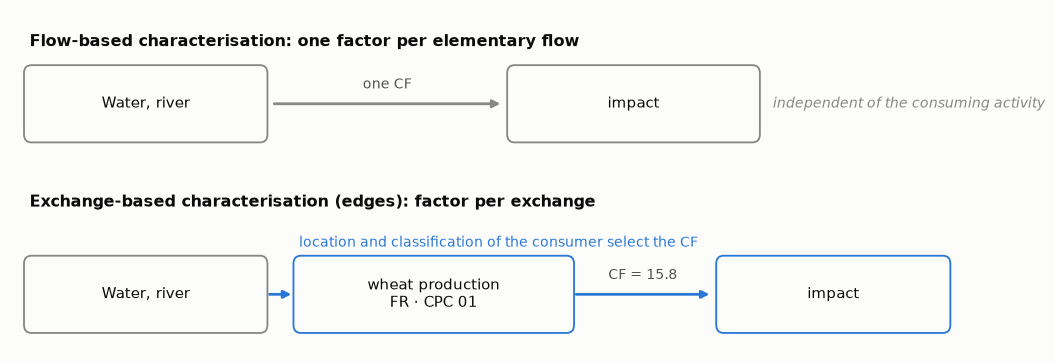

In [40]:
# Plot: flow-based vs exchange-based characterisation (schematic, no data).
fig, ax = plt.subplots(figsize=(10, 3.4))
ax.set_xlim(-0.2, 10.5); ax.set_ylim(0.1, 3.5); ax.axis("off")


def node(x, y, w, h, label, edge=MUTED, face=SURFACE, text_color=INK, weight="normal"):
    ax.add_patch(mpl.patches.FancyBboxPatch(
        (x, y), w, h, boxstyle="round,pad=0.06,rounding_size=0.08",
        linewidth=1.2, edgecolor=edge, facecolor=face))
    ax.text(x + w / 2, y + h / 2, label, ha="center", va="center",
            fontsize=9.5, color=text_color, fontweight=weight)


def arrow(x1, y, x2, color=MUTED, label=None, label_color=INK_2, style="-"):
    ax.annotate("", xy=(x2, y), xytext=(x1, y),
                arrowprops=dict(arrowstyle="-|>", color=color, linewidth=1.8, linestyle=style))
    if label:
        ax.text((x1 + x2) / 2, y + 0.12, label, ha="center", va="bottom",
                fontsize=9, color=label_color)


ax.text(0, 3.15, "Flow-based characterisation: one factor per elementary flow", fontsize=10.5,
        color=INK, fontweight="bold")
node(0, 2.25, 2.5, 0.65, "Water, river")
arrow(2.6, 2.575, 5.1, MUTED, "one CF")
node(5.2, 2.25, 2.6, 0.65, "impact")
ax.text(8.0, 2.575, "independent of the consuming activity", fontsize=9, color=MUTED, va="center", style="italic")

ax.text(0, 1.55, "Exchange-based characterisation (edges): factor per exchange", fontsize=10.5,
        color=INK, fontweight="bold")
node(0, 0.35, 2.5, 0.65, "Water, river")
node(2.9, 0.35, 2.9, 0.65, "wheat production\nFR · CPC 01", edge=BLUE)
arrow(2.55, 0.675, 2.85, BLUE)
arrow(5.85, 0.675, 7.35, BLUE, "CF = 15.8")
node(7.45, 0.35, 2.4, 0.65, "impact", edge=BLUE)
ax.text(2.9, 1.15, "location and classification of the consumer select the CF", fontsize=9, color=BLUE)

plt.tight_layout()
plt.show()

---
# Why `edges` and BONSAI?

BONSAI is a global input-output database that covers the whole economy: all sectors and
countries, no cut-off, and final demand is modelled as activities (`F_HOUS|FR` is the final
consumption of French households). For a consumption footprint this means nothing is left out,
and every activity already has a location, which is what a regionalised method needs. BONSAI is
open data, so anyone can reproduce the results.

`edges` matches the characterisation factors on the exchange, so an inventory with located
activities gets regionalised results without duplicating elementary flows. The methods are JSON
files that come with the package, so there is nothing to import and they can be read and
version-controlled like code.


### The method file

In [41]:
method_path = EDGES_DATA_DIR / ("_".join(METHOD) + ".json")
aware = json.loads(method_path.read_text(encoding="utf-8"))
print(f"{method_path.name}: {len(aware['exchanges']):,} CFs in {aware['unit']}")

# one CF record: river water used by agriculture in France
example = next(
    cf for cf in aware["exchanges"]
    if cf["consumer"].get("location") == "FR"
    and cf["supplier"]["name"] == "Water, river"
    and (cf["consumer"].get("classifications") or {}).get("CPC") == ["01"]
)
print(json.dumps({k: example[k] for k in ("supplier", "consumer", "value", "weight")}, indent=2))

AWARE 2.0_Country_all_yearly.json: 9,960 CFs in m3 deprived water-eq.
{
  "supplier": {
    "name": "Water, river",
    "categories": [
      "natural resource",
      "in water"
    ],
    "matrix": "biosphere"
  },
  "consumer": {
    "location": "FR",
    "matrix": "technosphere",
    "classifications": {
      "CPC": [
        "01"
      ]
    }
  },
  "value": 15.8,
  "weight": 5906520000
}


The supplier is the elementary flow, the consumer is any activity in `FR` classified as `CPC 01`
(crops). The `weight` is the water use in that context and is used when factors have to be
averaged over a larger region. Extraction has a positive factor and water returned to the
environment a negative one, so the score is for net consumption.

### Geography

In [42]:
def method_to_frame(method_json: dict) -> pd.DataFrame:
    rows = []
    for cf in method_json["exchanges"]:
        supplier, consumer = cf["supplier"], cf["consumer"]
        cpc = (consumer.get("classifications") or {}).get("CPC")
        rows.append({
            "flow": supplier["name"],
            "compartment": " / ".join(supplier.get("categories", [])),
            "role": "extraction" if cf["value"] > 0 else "release (credit)",
            "location": consumer.get("location"),
            "sector": ("irrigation (CPC 01)" if cpc == ["01"]
                       else "non-irrigation" if cpc else "unspecified"),
            "CF": cf["value"],
            "weight": cf.get("weight"),
            "uncertainty": (cf.get("uncertainty") or {}).get("distribution"),
        })
    return pd.DataFrame(rows)


CF_TABLE = method_to_frame(aware)
pairs = CF_TABLE.groupby(["flow", "compartment"]).ngroups
print(f"{len(CF_TABLE):,} CFs over {pairs} flow/compartment pairs"
      f" x {CF_TABLE.location.nunique()} locations x {CF_TABLE.sector.nunique()} sector contexts"
      f"  (not every combination exists)")

9,960 CFs over 10 flow/compartment pairs x 339 locations x 3 sector contexts  (not every combination exists)


In [43]:
# Irrigation factor per country (average over the water flows), from the method table
irrigation_cfs = (
    CF_TABLE.query("role == 'extraction' and sector == 'irrigation (CPC 01)'")
    .groupby("location", as_index=False)["CF"].mean()
    .sort_values("CF")
)
irrigation_cfs

,location,CF
32,BR-AM,0.209
107,CN-SH,0.243
27,BN,0.266
83,CN-AH,0.271
99,CN-JX,0.284
...,...,...
167,IL,93.800
10,AU-NSW,95.000
117,CY,95.700
280,SY,96.600


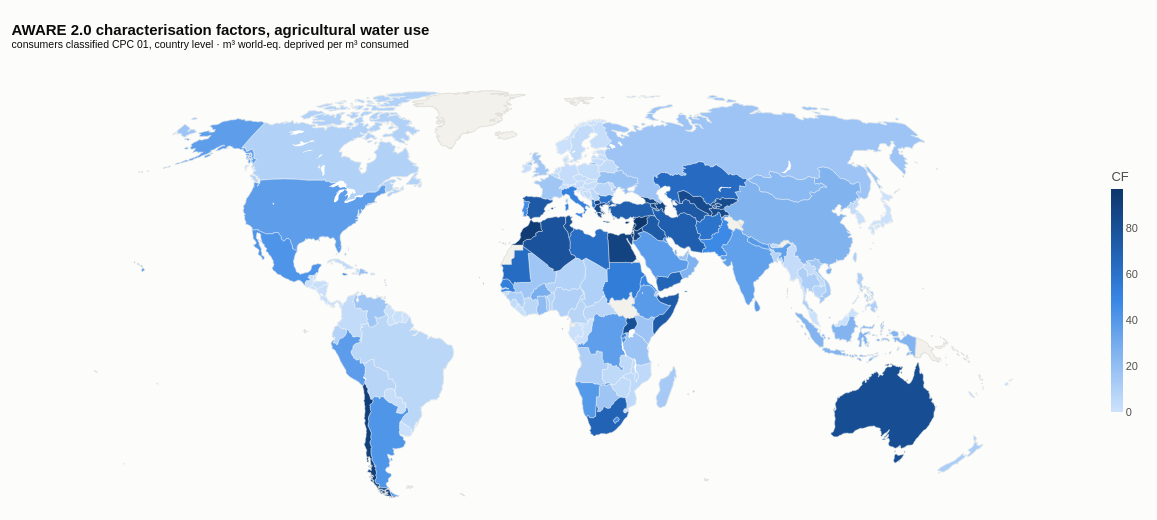

In [44]:
# Plot: map of the agricultural (CPC 01) characterisation factors.
choropleth(
    irrigation_cfs, "location", "CF",
    "AWARE 2.0 characterisation factors, agricultural water use",
    "consumers classified CPC 01, country level · m³ world-eq. deprived per m³ consumed",
    "CF",
).show()

The factors range from about 0.1 up to the cap of 100, so almost three orders of magnitude. A
single global average hides most of this.

### Consuming sector

In [45]:
# Factors by consuming sector for a few countries
focus = ["FR", "ES", "IT", "MA", "TN", "TR", "EG", "IN", "CN", "US", "BR", "DE", "NL", "PL", "MX"]
by_sector = (
    CF_TABLE.query("role == 'extraction' and location in @focus")
    .pivot_table(index="location", columns="sector", values="CF", aggfunc="mean")
    .rename(columns={"irrigation (CPC 01)": "irrigation", "non-irrigation": "industry & other"})
    .sort_values("irrigation")
)
by_sector.round(1)

sector,irrigation,industry & other,unspecified
location,,,
NL,2.2,1.9,1.9
DE,2.9,2.1,2.3
PL,3.0,3.2,3.2
BR,6.4,4.4,5.6
FR,15.8,5.0,13.0
CN,25.7,6.3,22.3
IN,35.9,37.9,36.2
US,37.4,11.3,33.7
MX,41.8,20.3,38.1


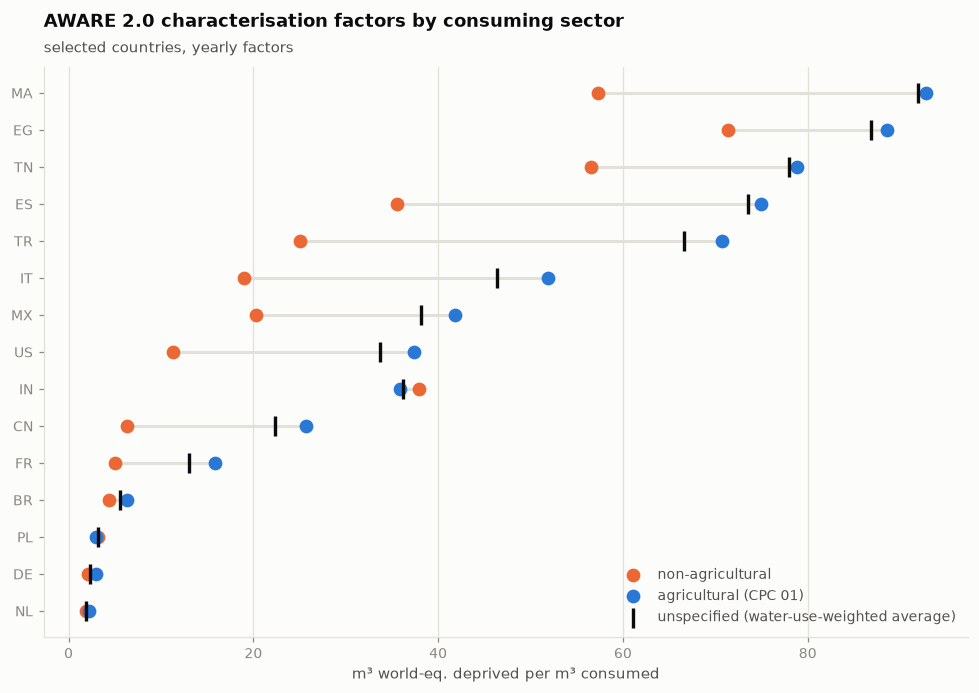

In [46]:
# Plot: agricultural vs non-agricultural factors per country; tick = unspecified.
fig, ax = plt.subplots(figsize=(9, 6.4))
y = np.arange(len(by_sector))
ax.hlines(y, by_sector["industry & other"], by_sector["irrigation"], color=GRID, linewidth=2, zorder=1)
ax.scatter(by_sector["industry & other"], y, color=ORANGE, zorder=3, label="non-agricultural")
ax.scatter(by_sector["irrigation"], y, color=BLUE, zorder=3, label="agricultural (CPC 01)")
ax.scatter(by_sector["unspecified"], y, color=INK, marker="|", s=170, linewidths=2.2, zorder=4,
           label="unspecified (water-use-weighted average)")
ax.set_yticks(y, by_sector.index)
style_ax(ax,
         title="AWARE 2.0 characterisation factors by consuming sector",
         subtitle="selected countries, yearly factors",
         xlabel="m³ world-eq. deprived per m³ consumed")
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

The black tick is the factor an activity without classification gets, i.e. the average of the
two weighted by the country's water use. In some countries it is close to the irrigation factor,
in others much lower.

---
# The calculation

`edges` matches each exchange to the method in five steps, in the order given in the method file:

| strategy | what it resolves | in BONSAI |
|---|---|---|
| `map_exchanges` | exact matches on location and classification | activities in countries: `FR`, `ES`, `IN`, … |
| `map_aggregate_locations` | activities in a region the method has no factor for | the five `W*` rest-of-world regions, averaged over their countries |
| `map_dynamic_locations` | `RoW`-style locations defined by exclusion | none in BONSAI, common in ecoinvent |
| `map_contained_locations` | activities inside a larger region that has a factor | sub-national datasets |
| `map_remaining_locations_to_global` | everything else | gets the global average |

For the aggregate step `edges` needs to know which countries are in regions like `WA` (rest of
Asia). Neither the method nor BONSAI has this information, so we provide it ourselves, based on
the EXIOBASE region definitions:

In [47]:
_correspondence = _CC.get_correspondence_dict("EXIO3", "ISO2")
REGIONS = {region: [c for c in (members or []) if c] for region, members in _correspondence.items()}
REGIONS["GB"] = ["GB"]      # coco maps GB into the EU28 bucket; BONSAI keeps it as a country
REGIONS["GR"] = ["GR"]

for region, members in sorted(((r, m) for r, m in REGIONS.items() if len(m) > 1),
                              key=lambda kv: -len(kv[1])):
    print(f"{region}: {len(members):3d} countries   e.g. {', '.join(members[:6])} …")

WA:  61 countries   e.g. AF, AS, AQ, AM, AZ, BD …
WF:  57 countries   e.g. DZ, AO, BJ, BW, BF, BI …
WL:  51 countries   e.g. AI, AG, AR, AW, BS, BB …
WE:  22 countries   e.g. AX, AL, AD, BY, BA, FO …
WM:  15 countries   e.g. BH, EG, IR, IQ, IL, JO …


In [48]:
def run_edges(demand, method=METHOD, regions=REGIONS) -> EdgeLCIA:
    """lci -> the method's own matching strategies -> evaluate -> lcia."""
    started = time.perf_counter()
    lca = EdgeLCIA({demand: 1}, method, additional_topologies=regions)
    lca.lci()
    lca.apply_strategies()              # the `strategies` list declared in the method file
    # keep the match counts: redo_lcia() re-runs the strategies and resets them
    lca.funnel = pd.DataFrame(lca.strategy_match_counts)
    lca.evaluate_cfs()
    lca.lcia()
    print(f"CF mapping: {time.perf_counter() - started:.1f} s")
    return lca


# Anchored on total French final demand: one CF mapping, covering a superset of every chain we
# look at later, so each further demand is a cheap `redo_lcia` instead of a second mapping.
LCA = run_edges(SETUP["anchor"])
LCA.redo_lcia({HOUSEHOLDS: 1})
MATCHED = LCA.generate_cf_table()
SCORE = float(np.sum(LCA.score))

print(f"CF mapping built once, on '{SETUP['anchor']['name']}'")
print(f"French households: {SCORE:,.4g} {aware['unit']}")


Finding direct matches        [1/5]
Resolving aggregate locations [2/5]
Resolving dynamic locations   [3/5]
Resolving contained locations [4/5]
Resolving global locations    [5/5]
CF mapping: 31.4 s
CF mapping built once, on 'total french cons'
French households: 1.82e+11 m3 deprived water-eq.


Lets check which parts were used to match the different locations

In [49]:
# Which matching step resolved how many exchanges
funnel = LCA.funnel.copy()
funnel["new matches"] = funnel.new_biosphere_matches + funnel.new_technosphere_matches
funnel[["strategy", "new matches", "cumulative_matches"]]

,strategy,new matches,cumulative_matches
0,map_exchanges,13458,13458
1,map_aggregate_locations,2315,15773
2,map_dynamic_locations,0,15773
3,map_contained_locations,0,15773
4,map_remaining_locations_to_global,0,15773


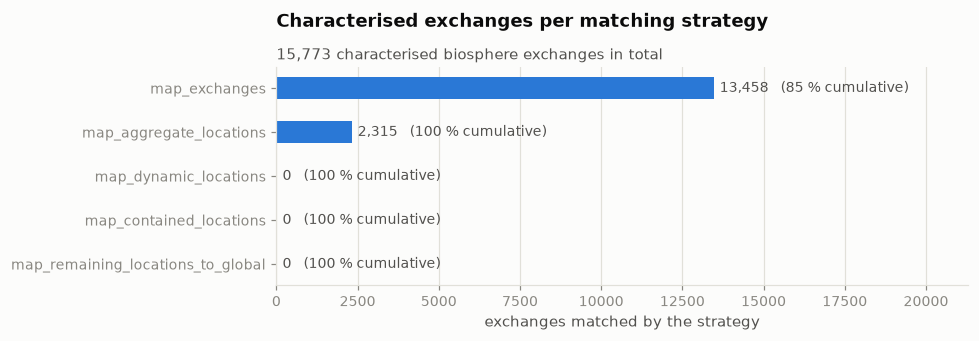

In [50]:
# Plot: matches per strategy.
total_matches = max(int(funnel.cumulative_matches.max()), 1)

fig, ax = plt.subplots(figsize=(9, 3.2))
y = np.arange(len(funnel))[::-1]
ax.barh(y, funnel["new matches"], height=0.5, color=BLUE)
ax.set_yticks(y, funnel.strategy)
for value, cumulative, pos in zip(funnel["new matches"], funnel.cumulative_matches, y):
    ax.text(value + 0.012 * total_matches, pos,
            f"{value:,.0f}   ({100 * cumulative / total_matches:.0f} % cumulative)",
            va="center", color=INK_2, fontsize=9)
ax.set_xlim(right=total_matches * 1.35)
style_ax(ax, title="Characterised exchanges per matching strategy",
         subtitle=f"{total_matches:,} characterised biosphere exchanges in total",
         xlabel="exchanges matched by the strategy")
plt.tight_layout(); plt.show()

---
# Where French consumption causes water scarcity

In [51]:
MATCHED["net m³"] = MATCHED["amount"] * np.sign(MATCHED["CF"])   # releases carry a negative CF
net_water = MATCHED["net m³"].sum()
abroad = MATCHED.loc[MATCHED["consumer location"] != "FR", "impact"].sum()

lines = [
    ("water consumed, net", f"{human(net_water)} m³"),
    ("water scarcity footprint", f"{human(SCORE)} m³ world-eq. deprived"),
    ("implied average factor", f"{SCORE / net_water:,.1f} m³ world-eq. / m³"),
    ("share outside France", f"{abroad / SCORE:.0%} of the water scarcity footprint"),
]
width = max(len(label) for label, _ in lines)
print(f"French households — {' '.join(METHOD)} · {SETUP['database'].name}\n" + "─" * 64)
for label, value in lines:
    print(f"{label.rjust(width)}   {value}")

French households — AWARE 2.0 Country all yearly · BONSAI v2.4.0
────────────────────────────────────────────────────────────────
     water consumed, net   8.35 billion m³
water scarcity footprint   182.05 billion m³ world-eq. deprived
  implied average factor   21.8 m³ world-eq. / m³
    share outside France   70% of the water scarcity footprint


In [52]:
by_location = (
    LCA.generate_cf_table(split_aggregate_consumers=True)      # W* regions split into members
    .groupby("consumer location", as_index=False)
    .agg(impact=("impact", "sum"), amount=("amount", "sum"))
)
by_location["share %"] = 100 * by_location.impact / by_location.impact.sum()

by_location.nlargest(10, "impact")

,consumer location,impact,amount,share %
49,FR,5.508885e+10,1.592781e+10,30.260392
46,ES,5.136340e+10,1.246837e+09,28.213996
75,IT,1.454295e+10,4.043886e+08,7.988468
160,US,8.078267e+09,6.360621e+08,4.437405
155,TR,5.578619e+09,9.191309e+07,3.064345
95,MA,4.384525e+09,6.207115e+07,2.408427
28,CL,4.193286e+09,1.274151e+08,2.303379
166,ZA,2.621765e+09,5.025970e+07,1.440140
108,MX,2.262945e+09,7.842628e+07,1.243039
123,PK,2.081493e+09,9.600529e+07,1.143367


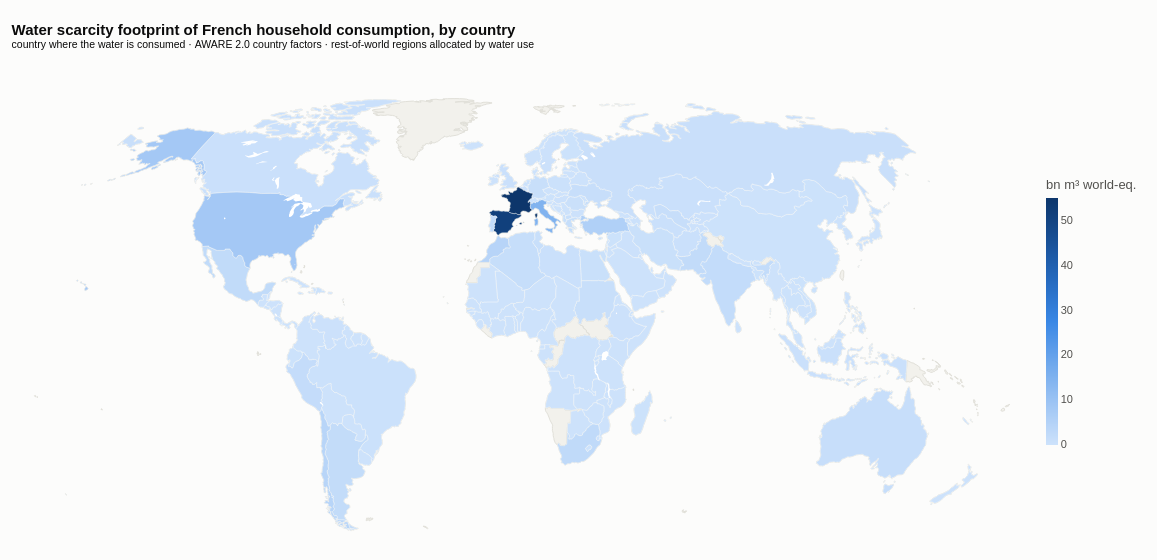

In [53]:
# Plot: world map of the impact per country.
choropleth(
    by_location.assign(impact_bn=by_location.impact / 1e9), "consumer location", "impact_bn",
    "Water scarcity footprint of French household consumption, by country",
    "country where the water is consumed · AWARE 2.0 country factors · rest-of-world regions "
    "allocated by water use",
    "bn m³ world-eq.", height=560,
).show()

The rest-of-world regions are split over their countries with the same water-use weights `edges`
used to build the regional factors. This is an assumption (water is consumed where water is used),
but it is the best we can do when the inventory only says "rest of Asia".

Ranking the countries by water volume or by scarcity-weighted impact gives quite different results:

In [54]:
# Share of water volume and share of impact per country
volumes = (
    LCA.generate_cf_table(split_aggregate_consumers=True)
    .assign(net=lambda d: d["amount"] * np.sign(d["CF"]))
    .groupby("consumer location", as_index=False)["net"].sum()
)
ranking = by_location.merge(volumes, on="consumer location", how="left")
ranking["volume %"] = 100 * ranking["net"] / ranking["net"].sum()
ranking["impact %"] = 100 * ranking["impact"] / ranking["impact"].sum()

ranking.nlargest(12, "impact %")[["consumer location", "volume %", "impact %"]].round(1)

,consumer location,volume %,impact %
49,FR,50.7,30.3
46,ES,8.4,28.2
75,IT,3.8,8.0
160,US,2.9,4.4
155,TR,1.0,3.1
95,MA,0.6,2.4
28,CL,0.5,2.3
166,ZA,0.5,1.4
108,MX,0.7,1.2
123,PK,0.5,1.1


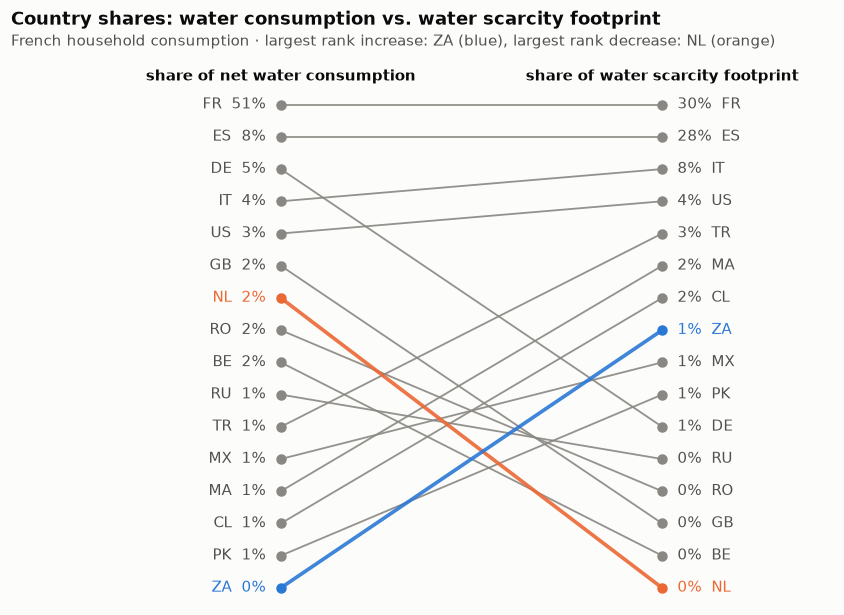

In [55]:
# Plot: slopegraph from volume ranking to impact ranking (countries with >= 1 % of either).
material = ranking[ranking[["volume %", "impact %"]].max(axis=1) >= 1]
shortlist = material.nlargest(10, "volume %").merge(material.nlargest(10, "impact %"), how="outer")
left_rank = shortlist.sort_values("volume %", ascending=False).reset_index(drop=True)
right_rank = shortlist.sort_values("impact %", ascending=False).reset_index(drop=True)
positions_left = {row["consumer location"]: i for i, row in left_rank.iterrows()}
positions_right = {row["consumer location"]: i for i, row in right_rank.iterrows()}

moves = {c: positions_left[c] - positions_right[c] for c in positions_left}
riser, faller = max(moves, key=moves.get), min(moves, key=moves.get)

fig, ax = plt.subplots(figsize=(8.5, 6.2))
for country in positions_left:
    y1, y2 = positions_left[country], positions_right[country]
    colour, width_, zorder = MUTED, 1.2, 1
    if country == riser and moves[country] > 0:
        colour, width_, zorder = BLUE, 2.4, 3
    elif country == faller and moves[country] < 0:
        colour, width_, zorder = ORANGE, 2.4, 3
    ax.plot([0, 1], [y1, y2], color=colour, linewidth=width_, zorder=zorder, alpha=0.9)
    ax.scatter([0, 1], [y1, y2], color=colour, s=34, zorder=zorder + 1)
    v = float(left_rank.loc[left_rank["consumer location"] == country, "volume %"].iloc[0])
    i = float(right_rank.loc[right_rank["consumer location"] == country, "impact %"].iloc[0])
    ax.text(-0.04, y1, f"{country}  {v:.0f}%", ha="right", va="center", fontsize=9.5,
            color=colour if colour != MUTED else INK_2)
    ax.text(1.04, y2, f"{i:.0f}%  {country}", ha="left", va="center", fontsize=9.5,
            color=colour if colour != MUTED else INK_2)

ax.set_xlim(-0.45, 1.45); ax.set_ylim(len(positions_left) - 0.5, -0.8)
ax.axis("off")
ax.text(0, -0.75, "share of net water consumption", ha="center", fontsize=10, color=INK, fontweight="bold")
ax.text(1, -0.75, "share of water scarcity footprint", ha="center", fontsize=10, color=INK, fontweight="bold")
fig.text(0.02, 0.98, "Country shares: water consumption vs. water scarcity footprint",
         fontsize=12, fontweight="bold", color=INK, ha="left", va="top")
fig.text(0.02, 0.945,
         f"French household consumption · largest rank increase: {riser} (blue), "
         f"largest rank decrease: {faller} (orange)",
         fontsize=9.5, color=INK_2, ha="left", va="top")
fig.subplots_adjust(top=0.88)
plt.show()

Which part of consumption drives this? One LCIA per COICOP division (the UN classification of
household consumption), each a quick `redo_lcia` on the mapping from above:

In [56]:
# One LCIA per COICOP division, on the mapping built above
rows = []
for division in SETUP["divisions"]:
    LCA.redo_lcia({division: 1})
    table = LCA.generate_cf_table()
    rows.append({"division": str(division["name"]).replace(" hh dmd", ""),
                 "total": float(np.sum(LCA.score)),
                 "France": table.loc[table["consumer location"] == "FR", "impact"].sum()})
LCA.redo_lcia({HOUSEHOLDS: 1})            # back to French households
divisions = pd.DataFrame(rows)
divisions["abroad"] = divisions.total - divisions.France
divisions["% abroad"] = 100 * divisions.abroad / divisions.total
divisions.sort_values("total", ascending=False).round(1)

,division,total,France,abroad,% abroad
0,01 - food and non-alcoholic beverages,4.728533e+10,5.552165e+09,4.173316e+10,88.3
10,11 - restaurants and accommodation services,3.504576e+10,5.454285e+09,2.959148e+10,84.4
3,"04 - housing, water, electricity, gas and othe...",2.878134e+10,1.229627e+10,1.648507e+10,57.3
6,07 - transport,1.550281e+10,2.285540e+09,1.321727e+10,85.3
4,"05 - furnishings, household equipment and rout...",1.051658e+10,1.977456e+09,8.539127e+09,81.2
1,"02 - alcoholic beverages, tobacco and narcotics",8.360000e+09,9.215302e+08,7.438470e+09,89.0
12,"13 personal care, social protection and miscel...",4.629150e+09,2.367800e+09,2.261350e+09,48.9
5,06 - health,3.407098e+09,1.924166e+09,1.482932e+09,43.5
8,"09 - recreation, sport and culture",3.037628e+09,1.197176e+09,1.840452e+09,60.6
11,12 - insurance and financial services,2.614231e+09,1.174320e+09,1.439911e+09,55.1


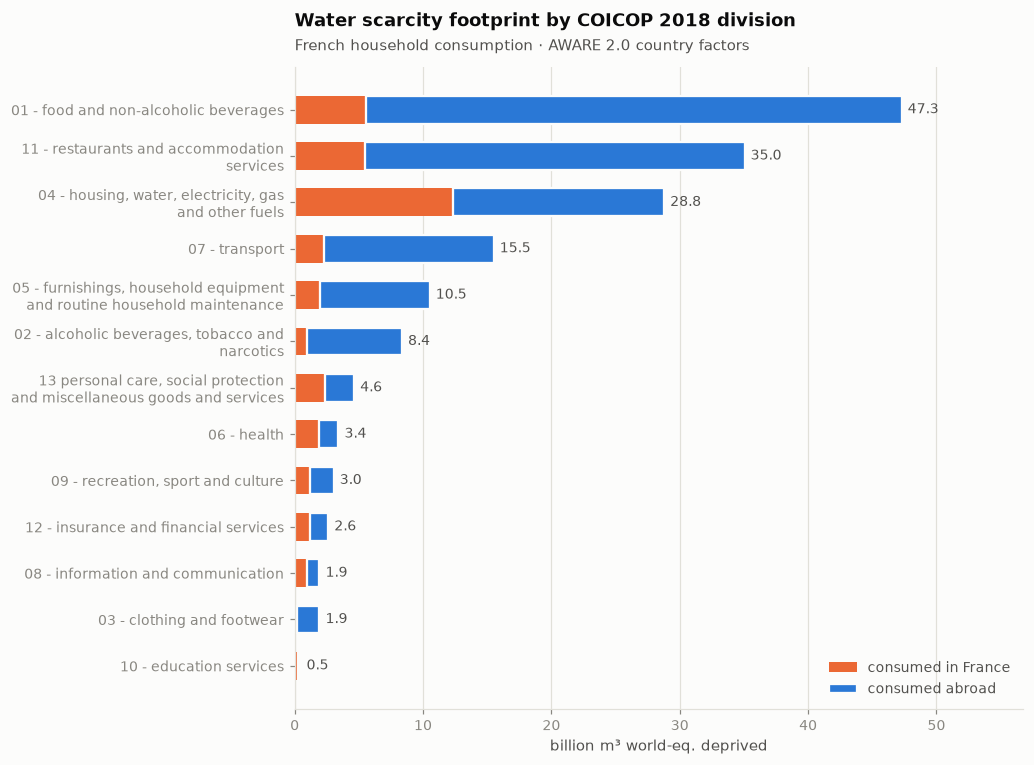

In [57]:
# Plot: COICOP divisions, water consumed in France vs abroad.
shown = divisions.sort_values("total").assign(
    France=lambda d: d.France / 1e9, abroad=lambda d: d.abroad / 1e9, total=lambda d: d.total / 1e9)
fig, ax = plt.subplots(figsize=(9.5, 1.6 + 0.42 * len(shown)))
y = np.arange(len(shown))
ax.barh(y, shown.France, height=0.6, color=ORANGE, label="consumed in France")
ax.barh(y, shown.abroad, left=shown.France, height=0.6, color=BLUE,
        label="consumed abroad", edgecolor=SURFACE, linewidth=1.5)
ax.set_yticks(y, wrap(shown.division, 38))
label_bars(ax, shown.total.tolist(), y, fmt="{:,.1f}")
ax.set_xlim(right=shown.total.max() * 1.2)
style_ax(ax, title="Water scarcity footprint by COICOP 2018 division",
         subtitle="French household consumption · AWARE 2.0 country factors",
         xlabel="billion m³ world-eq. deprived")
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()


---
# What regionalisation changes

We compare four ways to characterise the same inventory:

1. **Global average factor**: the world average weighted by water use, i.e. what a non-regionalised
   method does.
2. **French factor for all countries**: as if all the water was used in France.
3. **Country factors**: the calculation above.
4. **Country × sector factors**: country factors, plus the irrigation factor for activities that
   grow crops and the non-irrigation factor for everything else. Which activities grow crops
   comes from the BONSAI API.

The fourth one is not a new LCA run: we take the results table from the calculation above and
replace each factor with the country's irrigation or non-irrigation factor.

In [58]:
# --- reference factors, straight from the method file ---------------------------------
extraction = CF_TABLE.query("role == 'extraction'")
unspecified = extraction.query("sector == 'unspecified'")
GLOBAL_CF = float((unspecified.CF * unspecified.weight).sum() / unspecified.weight.sum())
FRENCH_CF = float(unspecified.loc[unspecified.location == "FR", "CF"].mean())

# --- which BONSAI activities grow crops, from the BONSAI API ---------------------------
# Every BONSAI product has a CPA code and every activity a reference product. AWARE gives the
# irrigation factor to crops (CPC 01); animal farming (CPC 02) gets the non-irrigation one.
# The API has the finer CPA code (01.1-01.3 crops, 01.4 animals) for part of the products only,
# so the remaining animals are listed here, together with manure treatment, which the API
# also files under CPA 01.
BONSAI_API = "https://lca.aau.dk/api/"
NOT_CROPS = {
    "A_Asses", "A_Buffaloes", "A_Bufmilk", "A_Camel", "A_Cammilk", "A_Othe_camel", "A_Cattle",
    "A_Chickens", "A_Cowmilk", "A_Goamilk", "A_Goat", "A_Pigs", "A_Sheep", "A_Shemilk",
    "A_Silkw", "A_MANC", "A_MA_LAND",
}


def bonsai_api(endpoint: str) -> list:
    """All pages of a BONSAI API endpoint (no account needed), cached in _cache/."""
    path = CACHE_DIR / f"bonsai_api_{endpoint.strip('/')}.json"
    if path.exists():
        return json.loads(path.read_text(encoding="utf-8"))
    import requests

    rows, url = [], BONSAI_API + endpoint
    while url:
        page = requests.get(url, headers={"Accept": "application/json"}, timeout=60)
        page.raise_for_status()
        data = page.json()
        rows += data["results"]
        url = (data.get("next") or "").replace("http://", "https://")
    path.write_text(json.dumps(rows), encoding="utf-8")
    return rows


def crop_activities() -> set:
    """BONSAI activity codes (without location) whose reference product is a crop."""
    products = {p["uuid"]: p for p in bonsai_api("products/")}
    fine = defaultdict(set)                       # product name -> CPA groups, where known
    for row in bonsai_api("product-corr/"):
        if row["source_class"] in ("CPA", "CPA21", "CPA 2.1") and row["source_code"]:
            fine[row["base_name"]].add(row["source_code"][:4])
    crops = set()
    for activity in bonsai_api("activities/"):
        product = products.get(activity["reference_flow"])
        if (activity["code"].startswith("A_") and product is not None
                and (product["cpa_category"] or "").zfill(2) == "01"
                and activity["code"] not in NOT_CROPS
                and "01.4" not in fine[product["name"]]):
            crops.add(activity["code"])
    return crops


CROPS = crop_activities()
BASE_CODE = {}                                    # activity name -> code without location
for activity in SETUP["database"]:
    BASE_CODE.setdefault(activity["name"], activity["code"].rsplit("|", 1)[0])


def is_crop(names: pd.Series) -> pd.Series:
    return names.map(lambda name: any(part in CROPS for part in BASE_CODE.get(name, "").split("|")))


sector_cfs = (
    extraction.pivot_table(index="location", columns="sector", values="CF", aggfunc="mean")
    .rename(columns={"irrigation (CPC 01)": "cf_irrigation", "non-irrigation": "cf_other"})
)
split = LCA.generate_cf_table(split_aggregate_consumers=True)
split["crop"] = is_crop(split["consumer name"])
split = split.merge(sector_cfs[["cf_irrigation", "cf_other"]],
                    left_on="consumer location", right_index=True, how="left")
resolved = split.cf_irrigation.notna()
sector_cf = np.where(split.crop, split.cf_irrigation, split.cf_other)
split["impact (sector-aware)"] = np.where(
    resolved, split["amount"] * np.sign(split["CF"]) * sector_cf, split["impact"]
)

print(f"world average factor {GLOBAL_CF:6.2f} · French factor {FRENCH_CF:6.2f} m³-eq / m³")
print(f"{len(CROPS)} BONSAI activities grow crops according to the BONSAI API")
print(f"{resolved.mean():.0%} of characterised edges sit in a country with sector-specific CFs; "
      f"{split.crop.mean():.0%} are crops, {split.loc[split.crop, 'impact'].sum() / split.impact.sum():.0%} "
      f"of the impact as run")

world average factor  36.43 · French factor  13.00 m³-eq / m³
174 BONSAI activities grow crops according to the BONSAI API
96% of characterised edges sit in a country with sector-specific CFs; 41% are crops, 35% of the impact as run


In [59]:
# The same inventory, characterised four ways
scenarios = pd.DataFrame([
    ("global average factor",         net_water * GLOBAL_CF),
    ("French factor for all countries", net_water * FRENCH_CF),
    ("country factors",               SCORE),
    ("country × sector factors",      split["impact (sector-aware)"].sum()),
], columns=["scenario", "score"])
scenarios["vs country"] = (100 * scenarios.score / SCORE - 100).round(1)
scenarios.assign(**{"score, bn": scenarios.score / 1e9}).drop(columns="score").round(1)

,scenario,vs country,"score, bn"
0,global average factor,67.1,304.2
1,French factor for all countries,-40.4,108.6
2,country factors,0.0,182.0
3,country × sector factors,-35.2,118.0


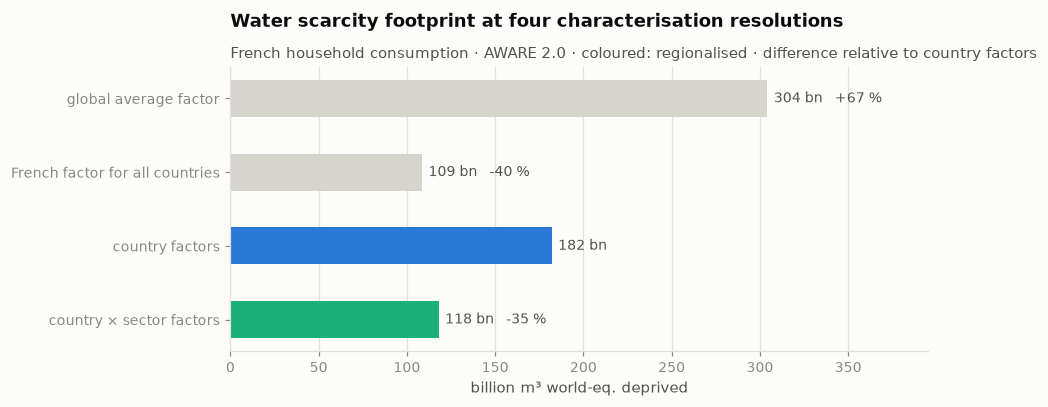

In [60]:
# Plot: four bars; regionalised results in colour.
scenarios["colour"] = [FILL_GREY, FILL_GREY, BLUE, AQUA]
fig, ax = plt.subplots(figsize=(9, 3.8))
y = np.arange(len(scenarios))[::-1]
ax.barh(y, scenarios.score / 1e9, height=0.5, color=scenarios.colour)
ax.set_yticks(y, scenarios.scenario)
for value, delta, pos in zip(scenarios.score, scenarios["vs country"], y):
    suffix = f"   {delta:+.0f} %" if delta else ""
    ax.text((value + 0.012 * scenarios.score.max()) / 1e9, pos, f"{value / 1e9:,.0f} bn{suffix}",
            va="center", color=INK_2, fontsize=9)
ax.set_xlim(right=scenarios.score.max() / 1e9 * 1.3)
style_ax(ax, title="Water scarcity footprint at four characterisation resolutions",
         subtitle="French household consumption · AWARE 2.0 · coloured: regionalised · "
                  "difference relative to country factors",
         xlabel="billion m³ world-eq. deprived")
plt.tight_layout(); plt.show()

The split comes from the BONSAI API: every BONSAI product has a CPA code, and CPA 01 is
agriculture. AWARE only gives the irrigation factor to crops (CPC 01); animal farming counts as
non-irrigation, so livestock and milk are left out (by their CPA code where the API has it,
otherwise from a short list in the cell). Food processing and aquaculture have their own CPA codes
and count as industry anyway.

### Where the sector matters

Knowing the sector does not change every country in the same way. Where most of the water goes to
crops (Morocco, India, Pakistan) almost nothing changes. Where it mostly goes to industry, power
plants and households (France, the US, China, Turkey) the result drops by half or more: there the
country average is close to the irrigation factor, but the water is not used for irrigation.

In [61]:
# Per country: impact with country factors and with country × sector factors, crops separately
by_country = (
    split.assign(crops=np.where(split.crop, split["impact"], 0.0),
                 crops_sector=np.where(split.crop, split["impact (sector-aware)"], 0.0))
    .groupby("consumer location")
    .agg(country=("impact", "sum"), sector=("impact (sector-aware)", "sum"),
         crops=("crops", "sum"), crops_sector=("crops_sector", "sum"))
    / 1e9
)
by_country["change %"] = 100 * (by_country.sector / by_country.country - 1)
by_country["crop share %"] = 100 * by_country.crops / by_country.country

by_country.nlargest(10, "country").round(1)

,country,sector,crops,crops_sector,change %,crop share %
consumer location,,,,,,
FR,55.1,23.6,2.9,3.5,-57.2,5.3
ES,51.4,40.4,29.1,29.6,-21.3,56.6
IT,14.5,8.1,3.1,3.4,-44.2,21.0
US,8.1,4.0,1.6,1.8,-50.7,20.3
TR,5.6,2.3,0.3,0.4,-58.0,6.2
MA,4.4,4.3,4.1,4.1,-2.6,93.1
CL,4.2,3.0,1.8,1.8,-28.5,43.2
ZA,2.6,2.5,1.7,1.8,-5.8,66.7
MX,2.3,1.9,1.3,1.4,-15.2,55.9


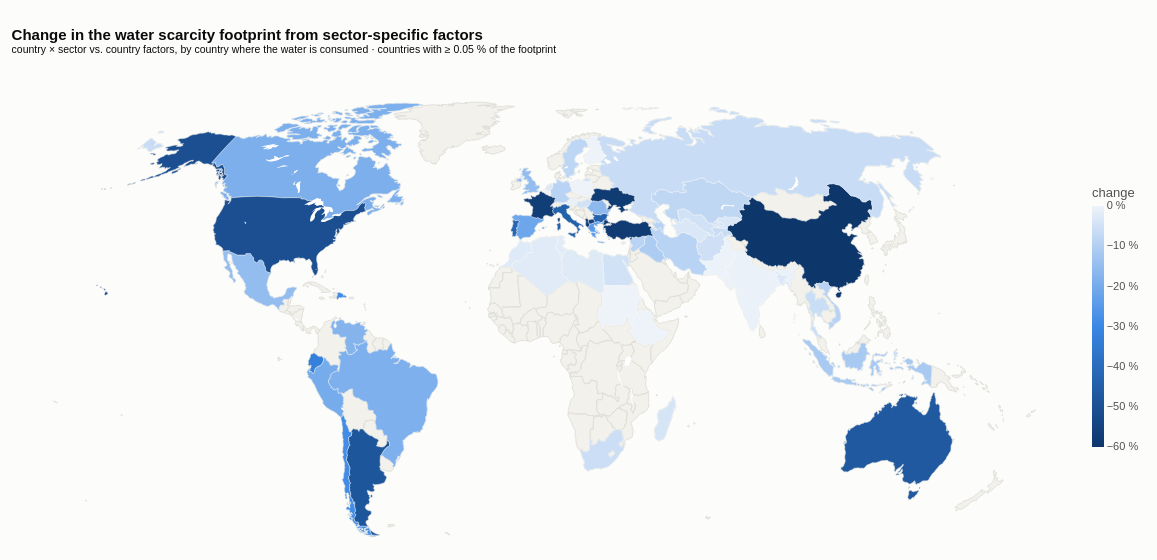

In [62]:
# Plot: map of the change per country (countries with at least 0.05 % of the footprint).
shown = by_country[(by_country.country >= 0.0005 * by_country.country.sum())
                   & (by_country.index.str.len() == 2)].reset_index()
shown["iso3"] = to_iso3(shown["consumer location"])
shown = shown.dropna(subset=["iso3"])
shown["country"] = country_names(shown["consumer location"])

figure = px.choropleth(
    shown, locations="iso3", color="change %", hover_name="country",
    hover_data={"iso3": False, "change %": ":.0f", "crop share %": ":.0f"},
    projection="natural earth", range_color=(-60, 0),
    color_continuous_scale=[(0, SEQ_BLUE[-1]), (0.5, SEQ_BLUE[3]), (1, "#eef3f9")],
)
figure.update_traces(marker_line_color=SURFACE, marker_line_width=0.4)
figure.update_geos(showcoastlines=False, showframe=False, showcountries=True, countrycolor=GRID,
                   landcolor="#f2f1ec", bgcolor=SURFACE, lataxis_range=[-58, 84])
figure.update_layout(
    title=dict(text="<b>Change in the water scarcity footprint from sector-specific factors</b>"
                    "<br><sup>country × sector vs. country factors, by country where the water is "
                    "consumed · countries with ≥ 0.05 % of the footprint</sup>",
               x=0.01, font=dict(size=15, color=INK)),
    coloraxis_colorbar=dict(title="change", ticksuffix=" %", thickness=12, len=0.6, outlinewidth=0),
    paper_bgcolor=SURFACE, height=560, margin=dict(l=10, r=10, t=80, b=10),
    font=dict(color=INK_2, size=11),
)
figure.show()

For the ten largest countries: the part used for crops (solid) stays about the same, the rest
(light) shrinks. France drops from 55 to 24 billion and falls behind Spain.

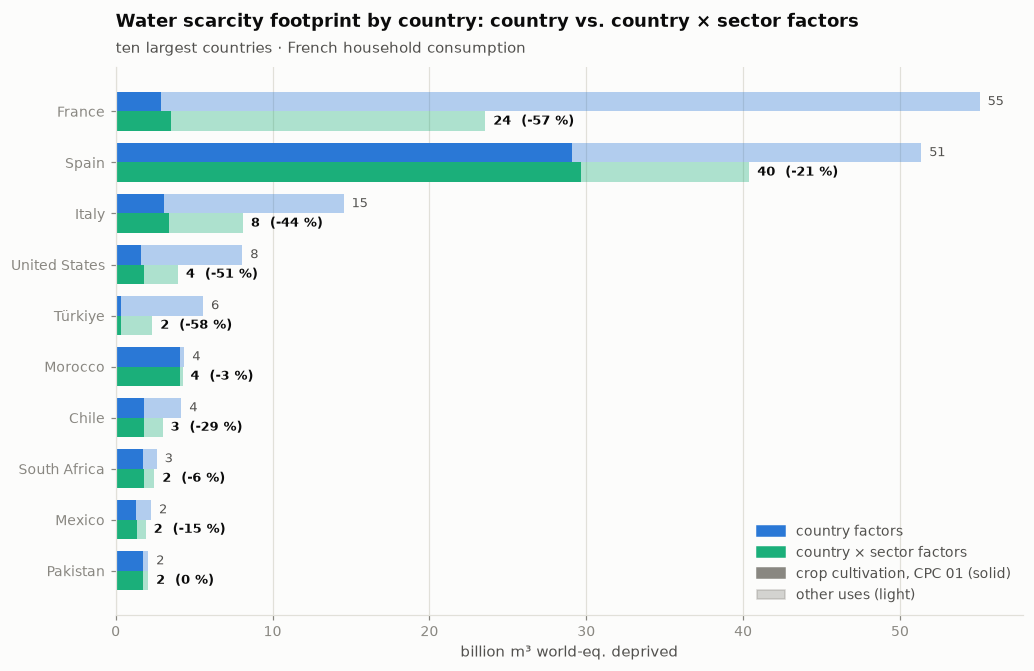

In [63]:
# Plot: top 10 countries, country vs country × sector factors, crops solid.
top = by_country.nlargest(10, "country").iloc[::-1]
names = country_names(top.index)

fig, ax = plt.subplots(figsize=(9.5, 6.2))
y, h = np.arange(len(top)), 0.38
for offset, total, crops, colour in [(h / 2, top.country, top.crops, BLUE),
                                     (-h / 2, top.sector, top.crops_sector, AQUA)]:
    ax.barh(y + offset, crops, height=h, color=colour)
    ax.barh(y + offset, total - crops, left=crops, height=h, color=colour, alpha=0.35)
for pos, (before, after) in enumerate(zip(top.country, top.sector)):
    ax.text(before + 0.5, pos + h / 2, f"{before:,.0f}", va="center", fontsize=8.5, color=INK_2)
    change = round(100 * (after / before - 1))
    ax.text(after + 0.5, pos - h / 2, f"{after:,.0f}  ({change:+d} %)".replace("+0 %", "0 %"),
            va="center", fontsize=8.5, color=INK, fontweight="bold")
ax.set_yticks(y, names)
ax.legend(handles=[mpl.patches.Patch(color=BLUE, label="country factors"),
                   mpl.patches.Patch(color=AQUA, label="country × sector factors"),
                   mpl.patches.Patch(color=MUTED, label="crop cultivation, CPC 01 (solid)"),
                   mpl.patches.Patch(color=MUTED, alpha=0.35, label="other uses (light)")],
          loc="lower right")
style_ax(ax, title="Water scarcity footprint by country: country vs. country × sector factors",
         subtitle="ten largest countries · French household consumption",
         xlabel="billion m³ world-eq. deprived")
plt.tight_layout(); plt.show()

---
# What is next?

* **Other impact categories.** Only the method changes: regionalised land use, eutrophication or
  acidification (e.g. GLAM or IMPACT World+ in `edges` format) run on the same inventory.
* **Supply chain relations.** `edges` can also put factors on the edges between activities (e.g.
  supply risk), only requires a mapping between BONSAI and the method's used classification.

---
# Conclusions

* We ran `edges` on BONSAI: regionalised LCIA on a global hybrid IO database covering the whole
  economy, with AWARE 2.0.
* 70 % of the scarcity-weighted water footprint of French households happens outside France. The
  ranking of countries changes with characterisation: France has half of the water volume but less
  than a third of the impact, Spain 8 % of the volume but 28 % of the impact.
* Resolution matters: a single global factor gives a result two thirds higher, and adding the
  sector split lowers it by about a third.
* Everything is open and can be reused: other methods, countries and scenarios only need a few
  lines to change.

### Links

* `edges`: <https://github.com/romainsacchi/edges> · docs <https://edges.readthedocs.io>
* BONSAI: <https://bonsai.uno/> · <https://github.com/BONSAMURAIS>
* AWARE: <https://wulca-waterlca.org/aware/>